# Real-Time Bitcoin Data Pipeline: Example Use Case

This notebook demonstrates an end-to-end use case of the Bitcoin Data Pipeline using Apache Airflow-compatible utility functions defined in `bitcoin_utils.py`.

## Objectives:
- Ingest real-time Bitcoin prices from the CoinGecko API.
- Store the raw data locally or in a mounted Airflow volume.
- Perform time series processing (moving average).
- Upload processed results to AWS S3.

## References:
-  API Documentation: [bitcoin.API.md](bitcoin.API.md)
-  Example Description: [bitcoin.example.md](bitcoin.example.md)
-  CoinGecko API: [https://www.coingecko.com/en/api](https://www.coingecko.com/en/api)


In [12]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports and Logging Setup


In [13]:
import os
import logging
import importlib
import matplotlib.pyplot as plt
import pandas as pd

# Set environment paths for local development
os.makedirs("./data", exist_ok=True)
os.environ["BITCOIN_RAW_PATH"] = "./data/bitcoin_raw.csv"
os.environ["BITCOIN_PROCESSED_PATH"] = "./data/bitcoin_processed.csv"

# Reload the utils module to apply path overrides
import bitcoin_utils
importlib.reload(bitcoin_utils)

# Logging config
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

### Fetch Real-Time Bitcoin Price


In [14]:
price_data = bitcoin_utils.fetch_bitcoin_price()
logger.info(price_data)

2025-05-07 23:58:50,333 - INFO - Fetched Bitcoin price successfully.
2025-05-07 23:58:50,345 - INFO - {'timestamp': '2025-05-08T03:58:50.341227', 'price_usd': 98971}


### Save Price to CSV

In [15]:
bitcoin_utils.save_price_to_csv()

2025-05-07 23:59:30,950 - INFO - Fetched Bitcoin price successfully.
2025-05-07 23:59:31,194 - INFO - Saved price to ./data/bitcoin_raw.csv


### Compute Moving Average


In [16]:
bitcoin_utils.compute_moving_average(window=2)

2025-05-08 00:00:02,253 - INFO - Processed data saved to ./data/bitcoin_processed.csv


### Visualize Processed Output

2025-05-08 00:00:40,453 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-08 00:00:40,473 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-08 00:00:40,499 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-08 00:00:40,507 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


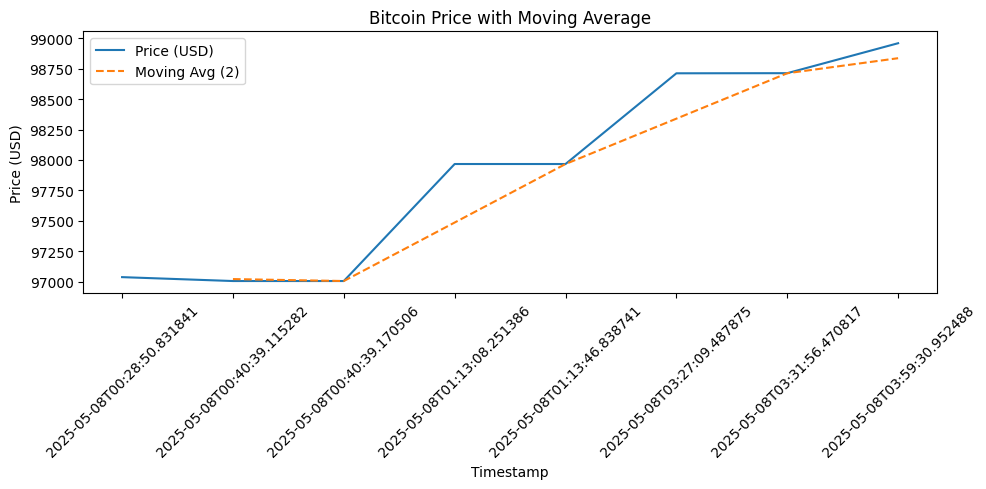

In [18]:
# Load and plot the result
processed_df = pd.read_csv("./data/bitcoin_processed.csv")

# Plot price and moving average
plt.figure(figsize=(10, 5))
plt.plot(processed_df['timestamp'], processed_df['price_usd'], label='Price (USD)')
plt.plot(processed_df['timestamp'], processed_df['price_ma'], label='Moving Avg (2)', linestyle='--')
plt.xticks(rotation=45)
plt.title("Bitcoin Price with Moving Average")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()


### Upload to AWS S3

In [ ]:
bitcoin_utils.upload_to_s3("bitcoin-price-store", "processed/bitcoin_processed.csv")